Plot the NN Performance
=======================

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as colors

import seaborn as sns

In [ ]:
def plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25,
    min_entries = 1,
    figsize_violin = (12, 6),
    figsize_summary = (8, 5),
    min_val = 0,
    max_val = 650
):
    """
    Make violin, bias, resolution, relative bias, and relative resolution plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing truth and prediction columns.
    truth_col : str
        Column name for true/reference value.
    pred_col : str
        Column name for predicted value.
    bin_width : float
        Width of truth bins, e.g. 20 for 20 cm bins.
    min_entries : int
        Minimum number of entries required in a bin to keep it.
    figsize_violin : tuple
        Figure size for violin plot.
    figsize_summary : tuple
        Figure size for summary plots.

    Returns
    -------
    work_df : pandas.DataFrame
        Copy of input dataframe with derived columns.
    summary : pandas.DataFrame
        Summary table with quantiles and derived metrics.
    """

    work_df = df.copy()

    # keep only finite values
    work_df = work_df[np.isfinite(work_df[truth_col]) & np.isfinite(work_df[pred_col])].copy()

    # derived columns
    work_df["diff"] = work_df[pred_col] - work_df[truth_col]

    # for relative quantities avoid division by zero
    work_df["rel_diff"] = np.nan
    nonzero = work_df[truth_col] != 0
    work_df.loc[nonzero, "rel_diff"] = (
        work_df.loc[nonzero, "diff"] / work_df.loc[nonzero, truth_col]
    )

    # define bins
    # min_val = np.floor(work_df[truth_col].min() / bin_width) * bin_width
    # max_val = np.ceil(work_df[truth_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    work_df["drift_bin"] = pd.cut(work_df[truth_col], bins = bins, right = False)

    # remove empty / too-small bins
    counts = work_df["drift_bin"].value_counts().sort_index()
    valid_bins = counts[counts >= min_entries].index
    work_df = work_df[work_df["drift_bin"].isin(valid_bins)].copy()

    # ordered labels for plotting
    work_df["drift_bin_label"] = work_df["drift_bin"].apply(
        lambda x: f"[{int(x.left)}, {int(x.right)})"
    )

    # absolute summary
    abs_summary = (
        work_df.groupby("drift_bin")["diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "diff_q16", 0.50: "diff_q50", 0.84: "diff_q84"})
    )

    # relative summary
    rel_summary = (
        work_df.dropna(subset = ["rel_diff"])
        .groupby("drift_bin")["rel_diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "rel_q16", 0.50: "rel_q50", 0.84: "rel_q84"})
    )

    # counts and x positions
    count_summary = work_df.groupby("drift_bin").size().to_frame("count")

    summary = abs_summary.join(rel_summary, how = "left").join(count_summary, how = "left").reset_index()

    summary["x_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
    summary["bin_label"] = summary["drift_bin"].apply(lambda b: f"[{int(b.left)}, {int(b.right)})")

    # absolute bias/resolution
    summary["bias"] = summary["diff_q50"]
    summary["bias_err_low"] = summary["diff_q50"] - summary["diff_q16"]
    summary["bias_err_high"] = summary["diff_q84"] - summary["diff_q50"]
    summary["resolution"] = (summary["diff_q84"] - summary["diff_q16"]) / 2.0

    # relative bias/resolution
    summary["rel_bias"] = summary["rel_q50"]
    summary["rel_bias_err_low"] = summary["rel_q50"] - summary["rel_q16"]
    summary["rel_bias_err_high"] = summary["rel_q84"] - summary["rel_q50"]
    summary["rel_resolution"] = (summary["rel_q84"] - summary["rel_q16"]) / 2.0

    # --------------------
    # 1. Violin plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_violin)
    plt.rcParams.update({"font.size": 16})

    sns.violinplot(
        data = work_df,
        x = "drift_bin_label",
        y = "diff",
        inner = "quartile",
        cut = 0,
        ax = ax
    )
    ax.set_xlabel(f"True average drift distance [cm]")
    ax.set_ylabel(f"Predicted - True drift distance [cm]")
    # ax.set_title("Distribution of prediction residuals by truth bin")
    ax.tick_params(axis = "x", labelrotation = 45)
    plt.tight_layout()
    plt.show()

    # --------------------
    # 2. Bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.errorbar(
        summary["x_center"],
        summary["bias"],
        yerr = [summary["bias_err_low"], summary["bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("Median of the Difference [cm]")
    ax.set_title("Prediction bias")
    ax.set_xlim([0, 650])
    ax.grid()
    
    plt.tight_layout()
    plt.show()

    # --------------------
    # 3. Resolution plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.plot(summary["x_center"], summary["resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the Difference [cm]")
    ax.set_title("Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()

    plt.tight_layout()
    plt.show()

    # --------------------
    # 4. Relative bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 5. Relative resolution plot
    # ---------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------
    # 6. Relative bias plot - y range [-0.2, 1]
    # --------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([-0.3, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 7. Relative resolution plot - y range [0, 1]
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    plt.rcParams.update({"font.size": 16})

    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([0, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    return work_df, summary

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5725/2445854888.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5725/2445854888.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5725/2445854888.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

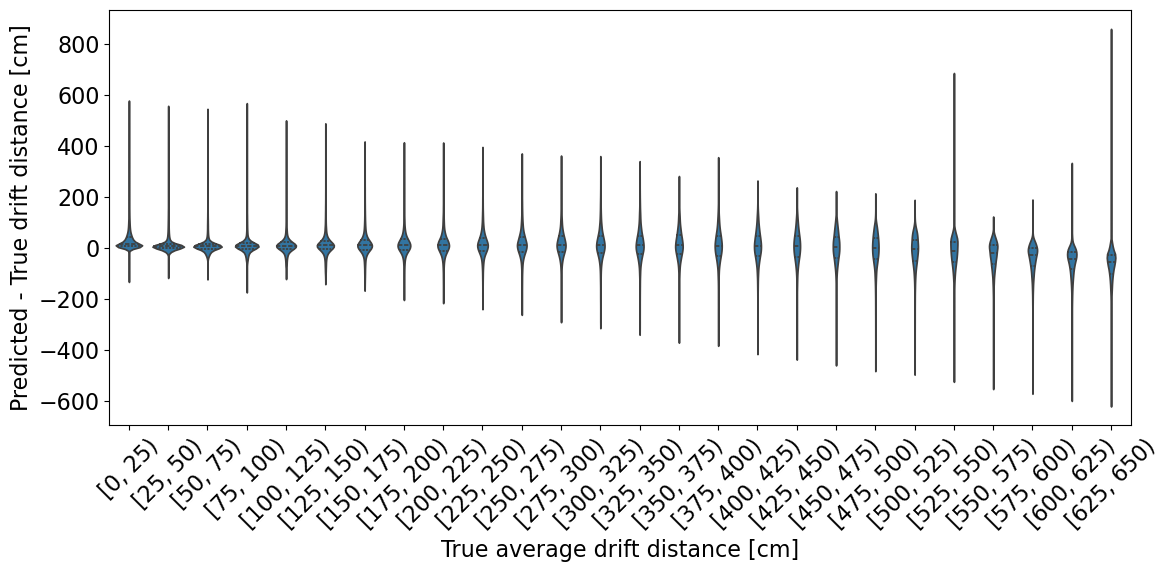

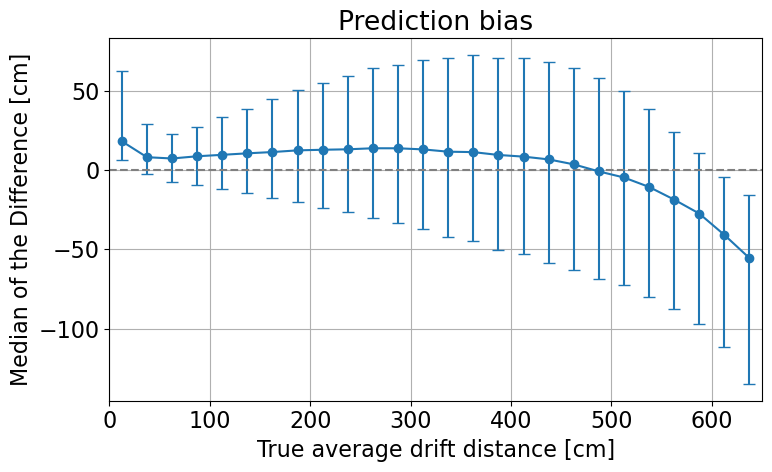

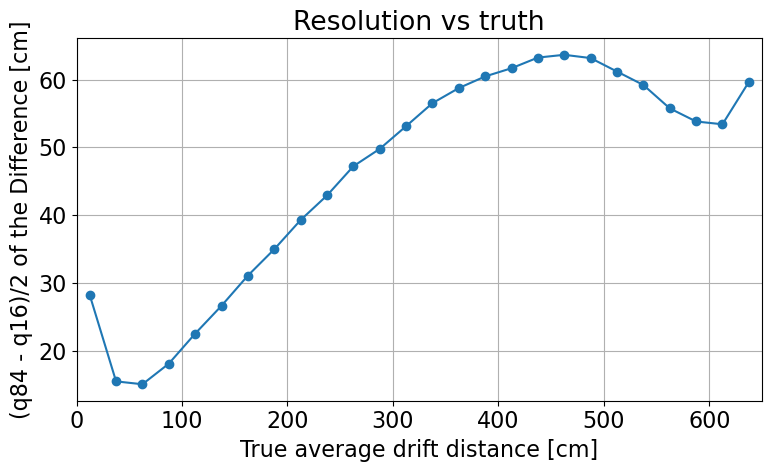

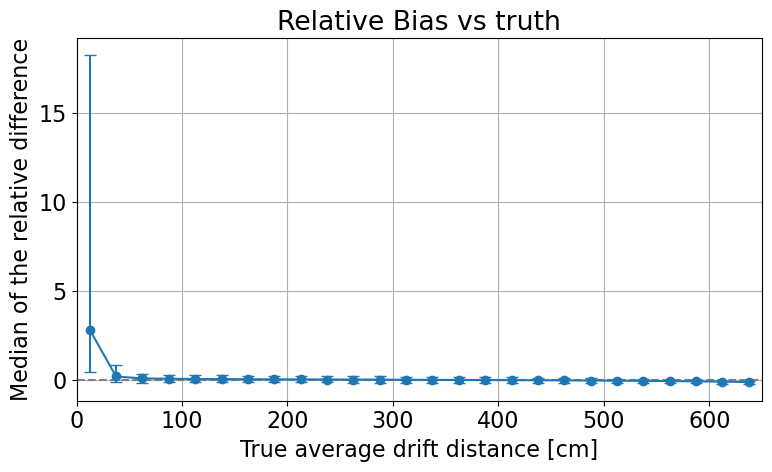

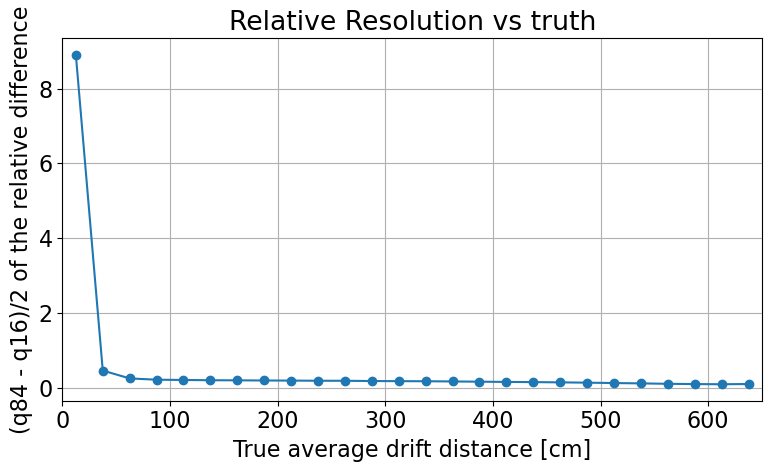

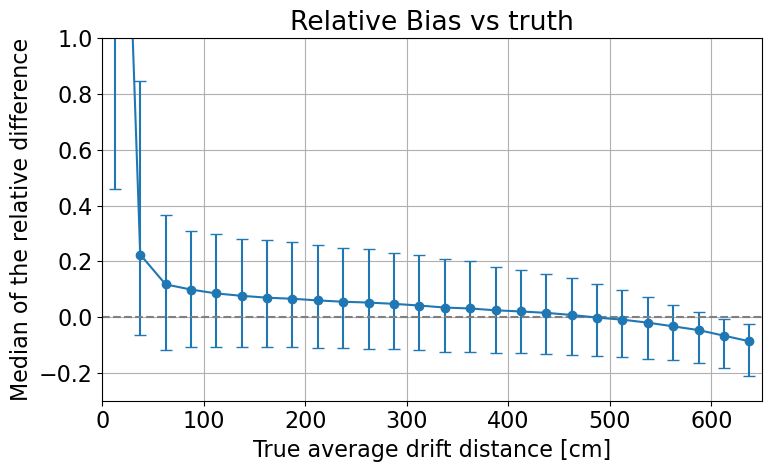

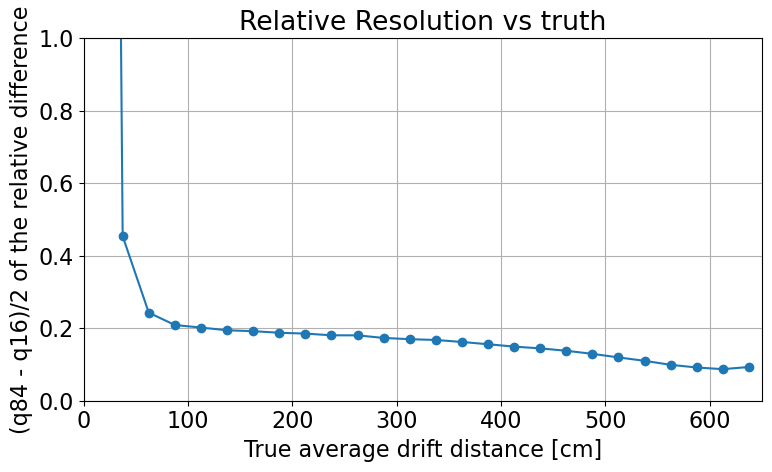

In [ ]:
work_df, summary = plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25
)